# Credit Card Fraud Detection

## Objective
Build and compare multiple classification models to detect fraudulent credit card transactions, with a focus on metrics that actually matter for a highly imbalanced, real-world fraud problem (not just accuracy).

## Dataset
- **Source:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (European cardholders, Sept 2013)
- **Rows:** ~284,807 transactions over 2 days
- **Features:**
  - `Time` — seconds elapsed since the first transaction in the dataset
  - `Amount` — transaction amount
  - `V1`–`V28` — anonymized features, already **PCA-transformed** for confidentiality (this is why they need no further scaling)
  - `Class` — target: `0` = genuine, `1` = fraud
- **Key characteristic:** extremely imbalanced — fraud is roughly **0.17%** of transactions. This drives almost every modeling decision below.

## Why accuracy alone is misleading here
A model that predicts "genuine" for every transaction scores **>99.8% accuracy** while catching **zero fraud**. Throughout this notebook we report **Precision, Recall, F1, ROC-AUC, and PR-AUC** for the fraud class, and treat accuracy as a secondary sanity check, not the headline number.


# 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. Load Data

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [4]:
df.sample(7)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0
101565,67878.0,-0.641330,-0.057304,1.489998,-1.688131,-1.151043,0.259996,-1.391069,-2.334075,1.168644,...,-1.231634,0.257164,-0.371953,-0.038566,1.397514,-0.665947,0.031003,0.180357,100.00,0
260880,159763.0,2.023952,-0.120140,-1.086918,0.423019,-0.142901,-1.127752,0.178493,-0.303234,0.564509,...,-0.276175,-0.697708,0.335631,-0.017196,-0.324904,0.200023,-0.071566,-0.058224,16.99,0


# 3. Data Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.804766e-12,-6.644561e-13,-5.732741e-13,7.602780e-13,2.290542e-13,6.119778e-14,3.241911e-14,-5.131429e-13,-7.735050e-13,...,-1.365218e-12,-7.572762e-13,-1.814506e-13,1.067891e-12,-6.013503e-13,-1.204939e-13,2.643612e-12,-3.222971e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.nunique()

Time      124592
V1        275653
V2        275655
V3        275657
V4        275654
V5        275657
V6        275652
V7        275651
V8        275643
V9        275656
V10       275646
V11       275648
V12       275654
V13       275657
V14       275653
V15       275653
V16       275645
V17       275646
V18       275655
V19       275645
V20       275633
V21       275618
V22       275644
V23       275613
V24       275645
V25       275640
V26       275647
V27       275601
V28       275564
Amount     32767
Class          2
dtype: int64

In [8]:
df.isnull()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
284803,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
284804,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
284805,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
print("Rows, Columns:", df.shape)
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values per column:\n", df.isnull().sum().sum(), "total missing values")

Rows, Columns: (284807, 31)

Duplicate rows: 1081

Missing values per column:
 0 total missing values


# 4. Data Cleaning

In [11]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")

Removed 1081 duplicate rows. New shape: (283726, 31)


# 5. Exploratory Data Analysis (EDA)

## 5.1 Class Imbalance — the central fact of this dataset

Counts:
 Class
0    283253
1       473
Name: count, dtype: int64

Percentage:
 Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


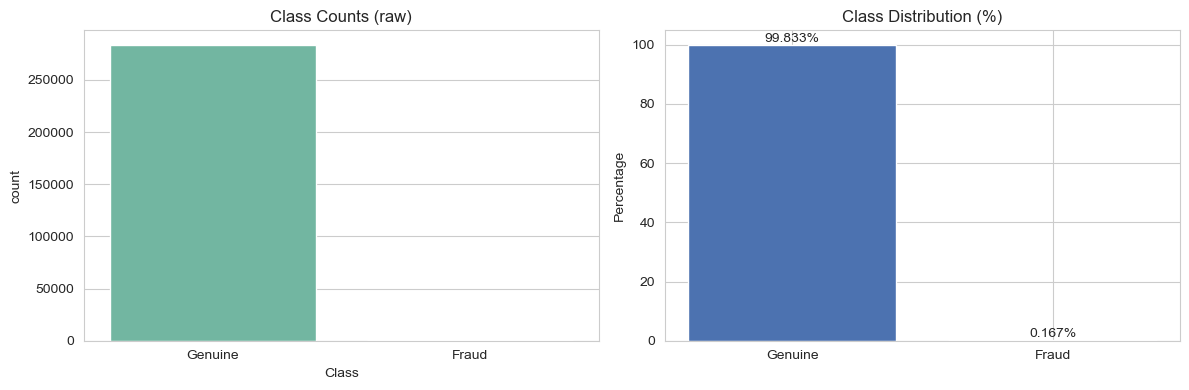


Fraud is only 0.167% of all transactions — this is why accuracy alone is a poor metric, and why class imbalance must be explicitly handled during modeling.


In [12]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Counts:\n", class_counts)
print("\nPercentage:\n", class_pct.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Class", data=df, ax=axes[0], hue="Class", palette="Set2", legend=False)
axes[0].set_title("Class Counts (raw)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Genuine", "Fraud"])

axes[1].bar(["Genuine", "Fraud"], class_pct.sort_index(), color=["#4C72B0", "#C44E52"])
axes[1].set_title("Class Distribution (%)")
axes[1].set_ylabel("Percentage")
for i, v in enumerate(class_pct.sort_index()):
    axes[1].text(i, v, f"{v:.3f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"\nFraud is only {class_pct[1]:.3f}% of all transactions — this is why accuracy alone "
      f"is a poor metric, and why class imbalance must be explicitly handled during modeling.")

## 5.2 Transaction Amount & Time

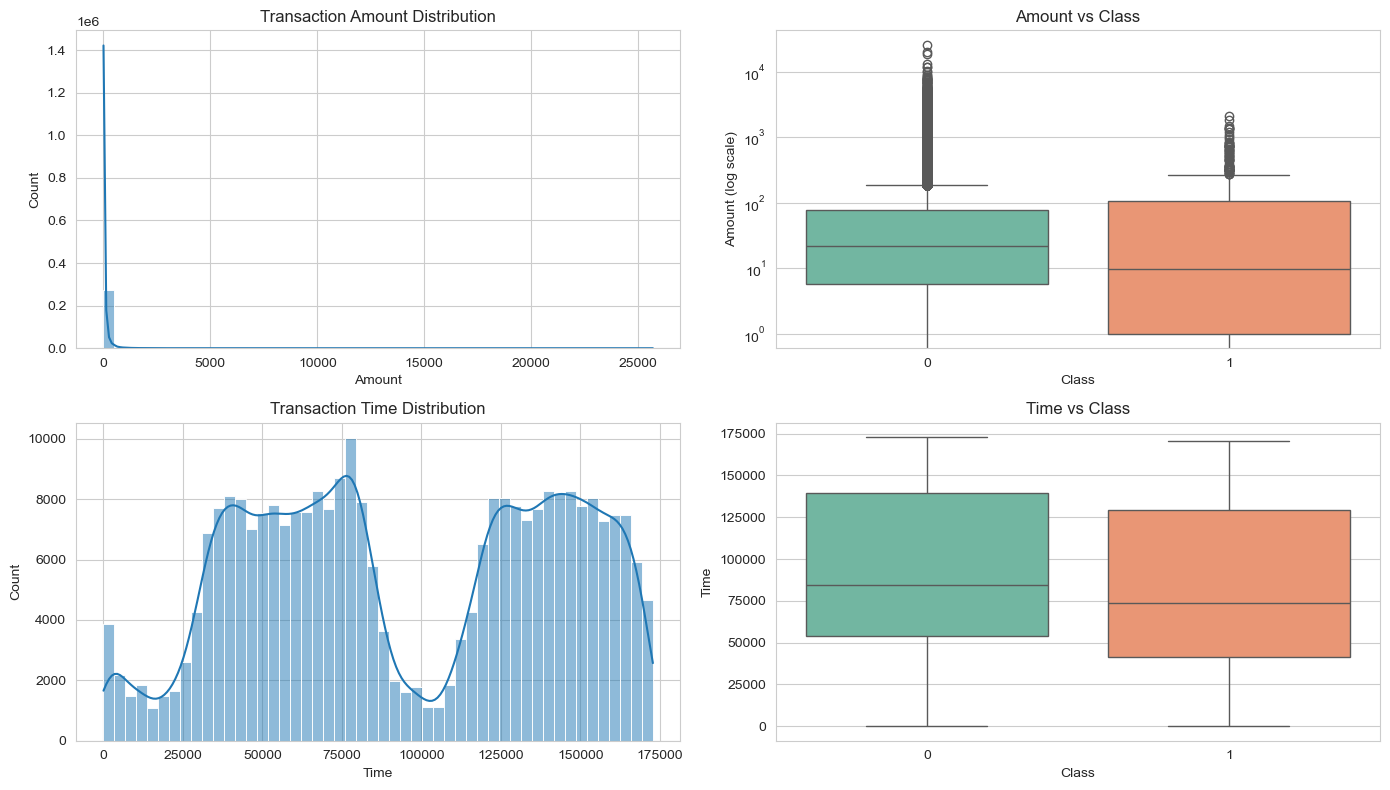

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df["Amount"], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Transaction Amount Distribution")

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0, 1], hue="Class", palette="Set2", legend=False)
axes[0, 1].set_title("Amount vs Class")
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("Amount (log scale)")

sns.histplot(df["Time"], bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Transaction Time Distribution")

sns.boxplot(x="Class", y="Time", data=df, ax=axes[1, 1], hue="Class", palette="Set2", legend=False)
axes[1, 1].set_title("Time vs Class")

plt.tight_layout()
plt.show()

**Note on outliers:** the boxplots above show a long tail in `Amount` — this is expected and *meaningful* for fraud detection (large transactions are disproportionately relevant), so we intentionally do **not** remove these as outliers. Clipping or removing them would throw away signal the model needs.

In [14]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

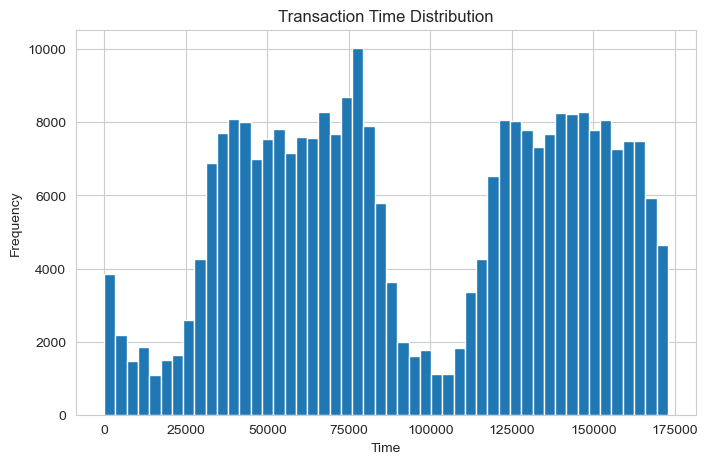

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

## 5.3 Correlation with the Target

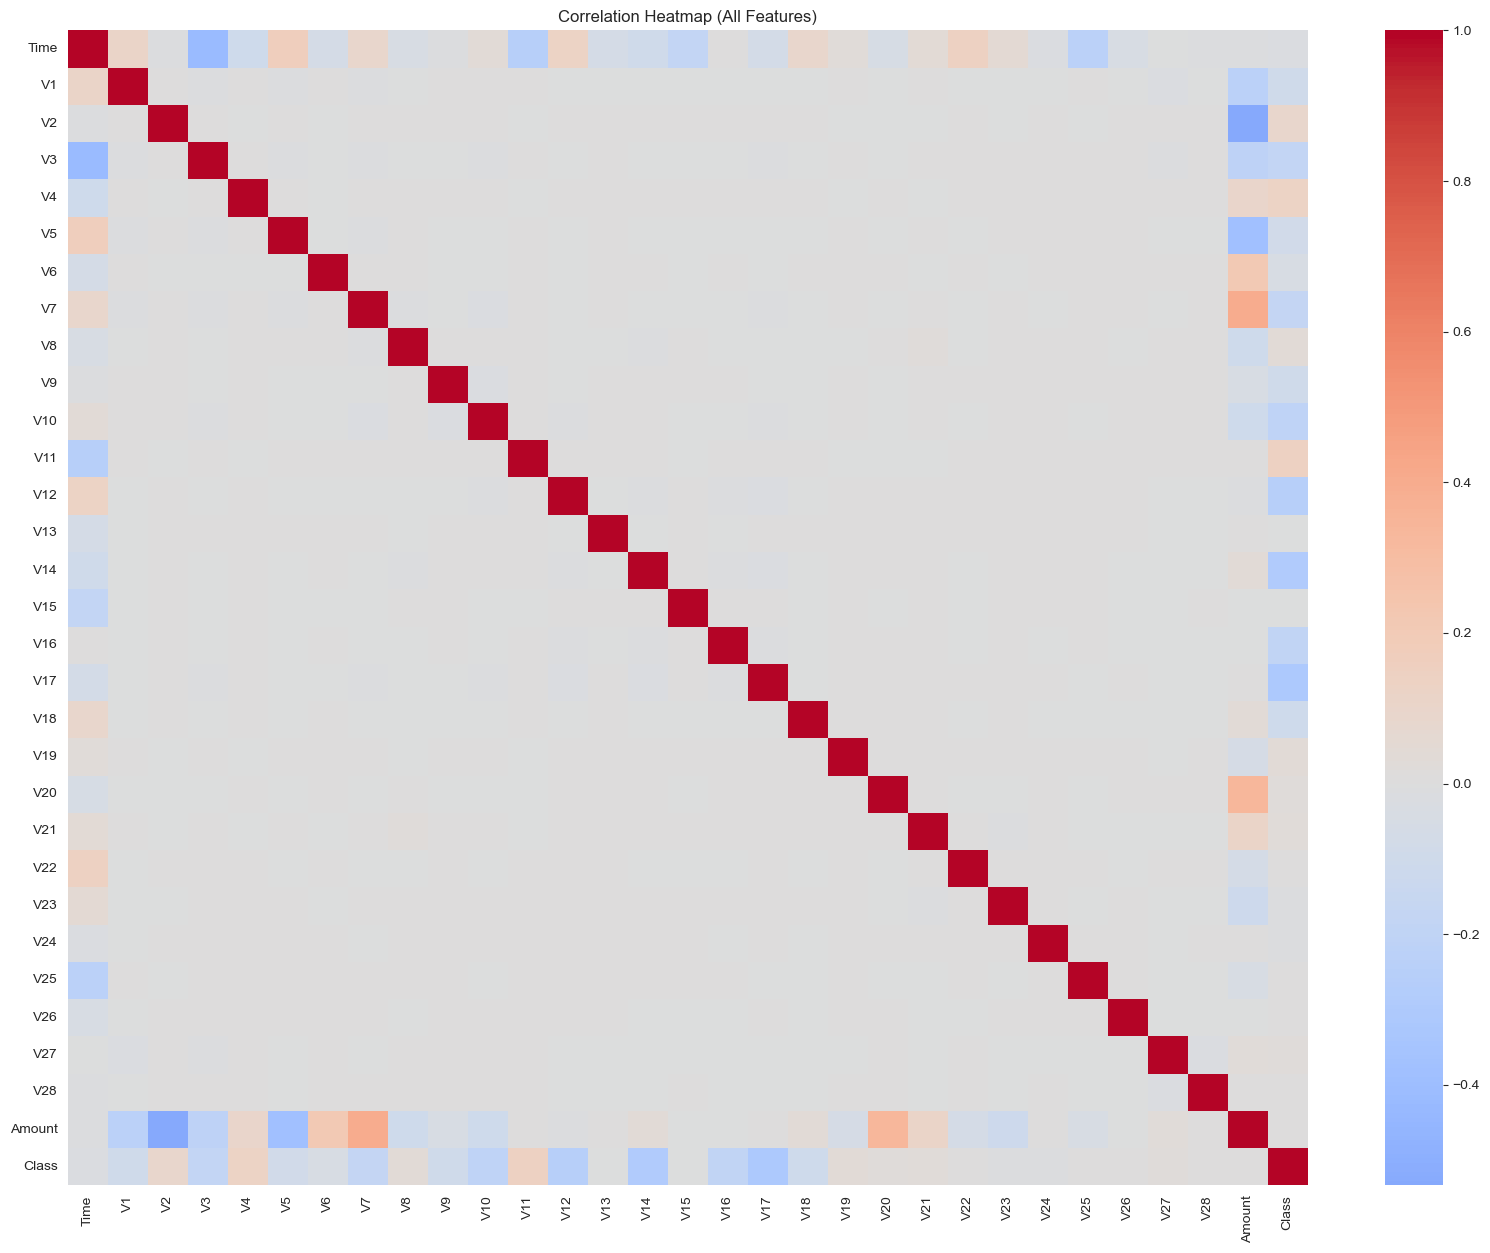

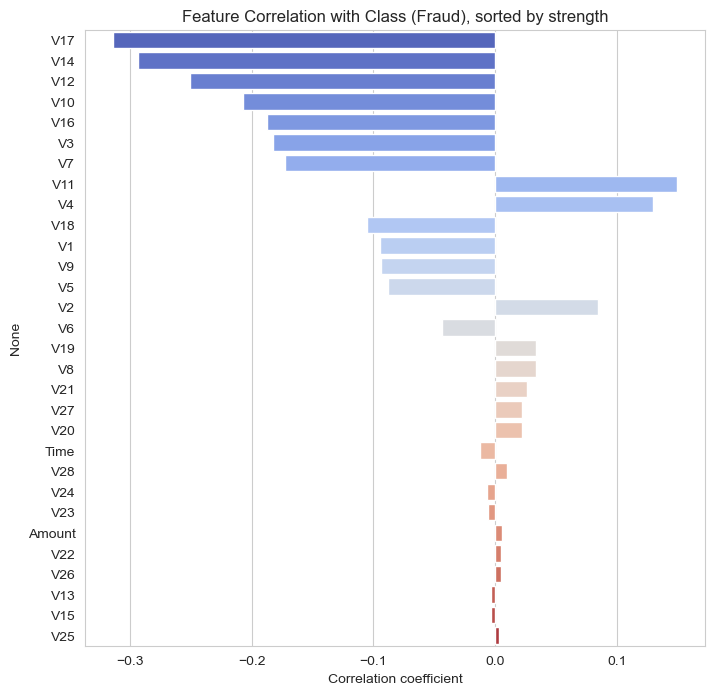

Top 5 features most correlated with fraud:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64


In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (All Features)")
plt.show()

# Which features correlate most strongly with fraud?
class_corr = corr["Class"].drop("Class").sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 8))
sns.barplot(x=class_corr.values, y=class_corr.index, hue=class_corr.index,
            palette="coolwarm", legend=False)
plt.title("Feature Correlation with Class (Fraud), sorted by strength")
plt.xlabel("Correlation coefficient")
plt.show()

print("Top 5 features most correlated with fraud:")
print(class_corr.head(5))

## 5.4 Time vs Amount, colored by Class

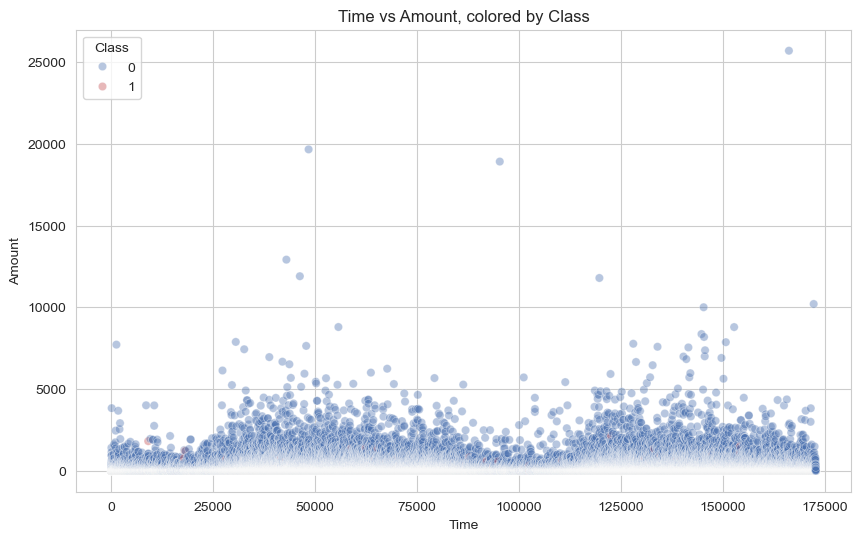

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Time", y="Amount", hue="Class", data=df, alpha=0.4, palette=["#4C72B0", "#C44E52"])
plt.title("Time vs Amount, colored by Class")
plt.show()

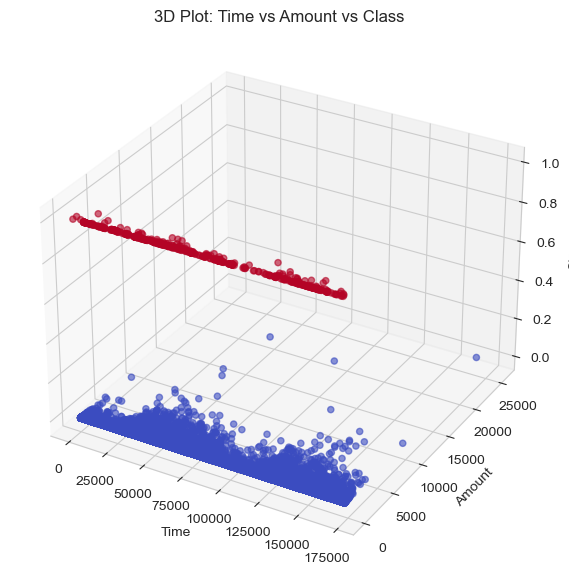

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df["Time"],
    df["Amount"],
    df["Class"],
    c=df["Class"],
    cmap="coolwarm",
    alpha=0.6
)

ax.set_xlabel("Time")
ax.set_ylabel("Amount")
ax.set_zlabel("Class")

plt.title("3D Plot: Time vs Amount vs Class")

plt.show()

# 6. Feature / Target Split

In [19]:
X = df.drop("Class", axis=1)
y = df["Class"]

# 7. Train-Test Split

 we use `stratify=y` so the train and test sets preserve the same (tiny) fraud ratio — with a 0.17% minority class, a non-stratified split can easily over/under-represent fraud cases in the test set purely by chance.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Fraud rate:", y_train.mean().round(5))
print("Test shape: ", X_test.shape, " Fraud rate:", y_test.mean().round(5))

Train shape: (226980, 30)  Fraud rate: 0.00167
Test shape:  (56746, 30)  Fraud rate: 0.00167


# 8. Feature Scaling
Here we fit the scaler **only on the training set** and apply it to both sets, which also avoids leaking test-set statistics into training. Only `Time` and `Amount` need scaling — `V1`–`V28` are already PCA-transformed (mean 0, unit-ish variance by construction).

In [21]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

X_train[["Time", "Amount"]].describe()

,Time,Amount
count,2.269800e+05,2.269800e+05
mean,-1.522636e-16,7.487965e-17
std,1.000002e+00,1.000002e+00
min,-1.998400e+00,-3.596386e-01
25%,-8.561822e-01,-3.364866e-01
50%,-2.123526e-01,-2.697972e-01
75%,9.363191e-01,-4.287453e-02
max,1.640237e+00,7.962087e+01


# 9. Evaluation Helper

Rather than repeating ~10 cells of near-identical metric/plotting code per model , we define one evaluation function and reuse it for every model. This also lets us build a single comparison table at the end.

In [22]:
results = {}  # collects metrics for the final comparison table

def evaluate_model(name, model, X_test, y_test, y_pred, y_score=None):
    """Compute metrics, print a report, and plot confusion / ROC / PR curves for one model.
    y_score: continuous scores (predict_proba[:,1] or decision_function) used for ROC/PR curves.
    """
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
    pr_auc = average_precision_score(y_test, y_score) if y_score is not None else np.nan

    results[name] = {
        "Accuracy": acc, "Precision (fraud)": prec, "Recall (fraud)": rec,
        "F1 (fraud)": f1, "ROC-AUC": roc_auc, "PR-AUC": pr_auc
    }

    print(f"===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}  (of transactions flagged as fraud, how many were real fraud)")
    print(f"Recall:    {rec:.4f}  (of actual fraud cases, how many were caught)")
    print(f"F1:        {f1:.4f}")
    if y_score is not None:
        print(f"ROC-AUC:   {roc_auc:.4f}")
        print(f"PR-AUC:    {pr_auc:.4f}  (more informative than ROC-AUC for rare classes)")
    print()
    print(classification_report(y_test, y_pred, target_names=["Genuine", "Fraud"]))

    n_plots = 3 if y_score is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Genuine", "Fraud"], yticklabels=["Genuine", "Fraud"], ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title(f"{name}: Confusion Matrix")

    if y_score is not None:
        RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
        axes[1].set_title(f"{name}: ROC Curve")

        PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=axes[2])
        axes[2].set_title(f"{name}: Precision-Recall Curve")

    plt.tight_layout()
    plt.show()

# 10. Model 1: Logistic Regression

`class_weight="balanced"` tells the model to weight the rare fraud class more heavily during training, instead of treating both classes as equally common.

===== Logistic Regression =====
Accuracy:  0.9752
Precision: 0.0562  (of transactions flagged as fraud, how many were real fraud)
Recall:    0.8737  (of actual fraud cases, how many were caught)
F1:        0.1057
ROC-AUC:   0.9658
PR-AUC:    0.6719  (more informative than ROC-AUC for rare classes)

              precision    recall  f1-score   support

     Genuine       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



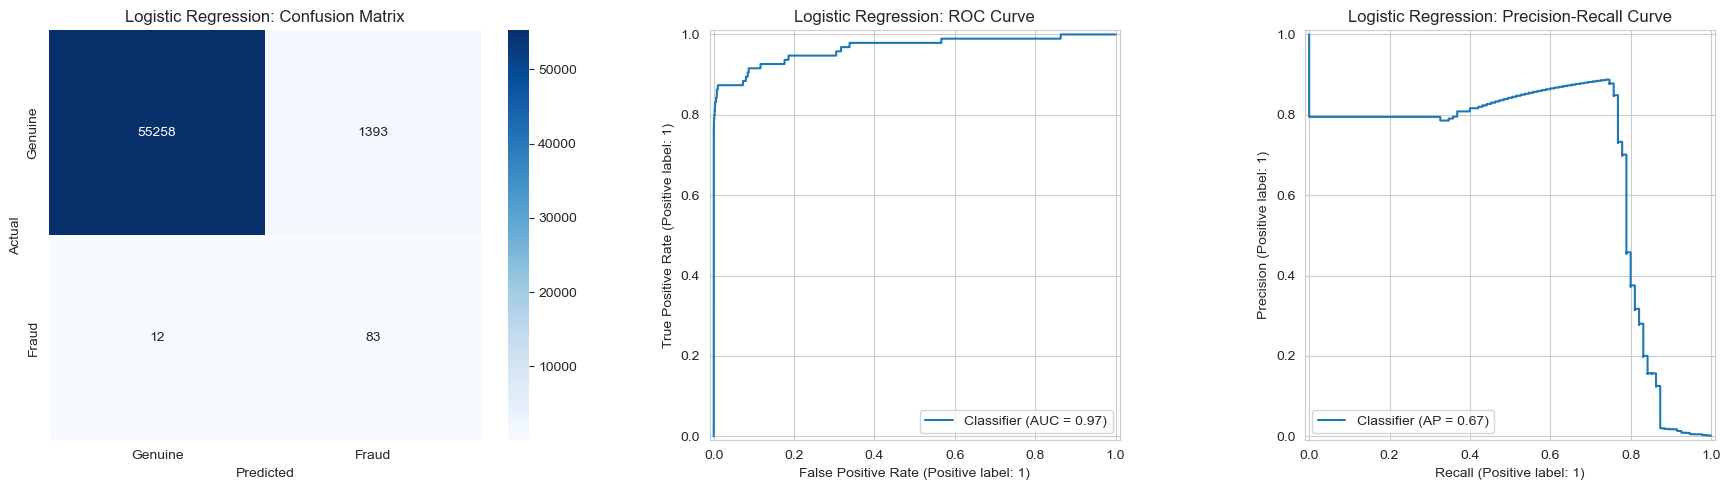

In [23]:
log_model = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced", max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_score_log = log_model.predict_proba(X_test)[:, 1]

evaluate_model("Logistic Regression", log_model, X_test, y_test, y_pred_log, y_score_log)

# 11. Model 2: Decision Tree

===== Decision Tree =====
Accuracy:  0.9990
Precision: 0.7349  (of transactions flagged as fraud, how many were real fraud)
Recall:    0.6421  (of actual fraud cases, how many were caught)
F1:        0.6854
ROC-AUC:   0.8209
PR-AUC:    0.4725  (more informative than ROC-AUC for rare classes)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.73      0.64      0.69        95

    accuracy                           1.00     56746
   macro avg       0.87      0.82      0.84     56746
weighted avg       1.00      1.00      1.00     56746



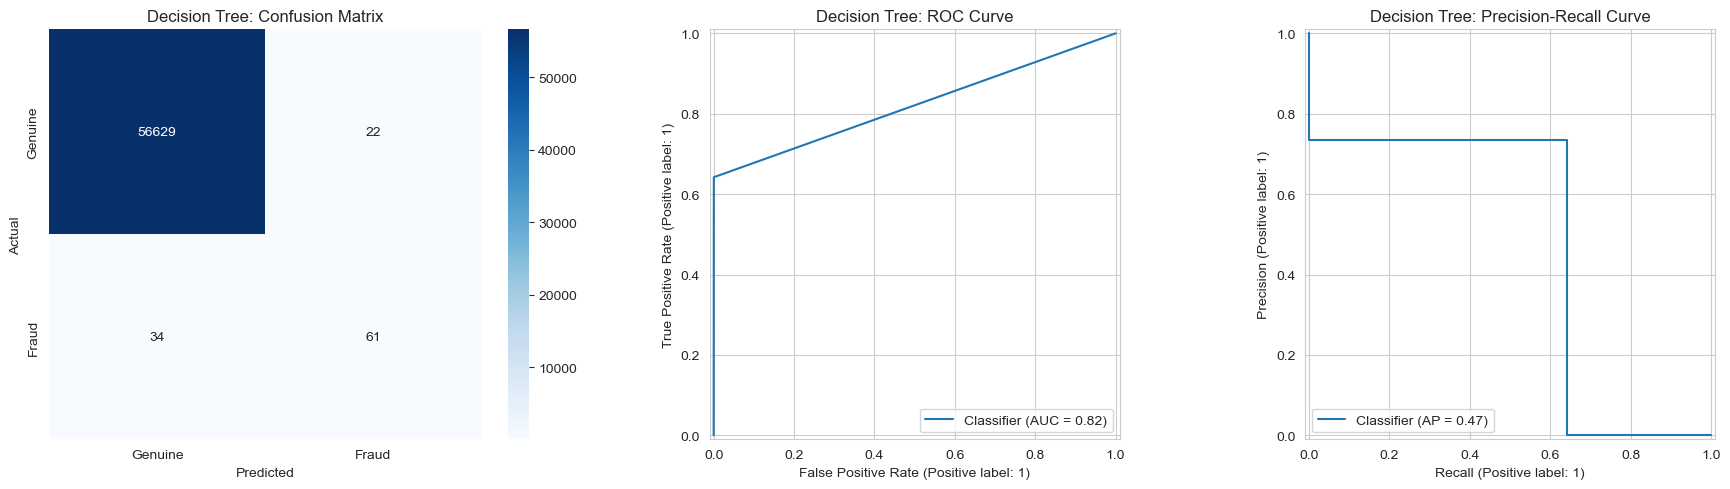

In [24]:
dt_model = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE, class_weight="balanced")
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_score_dt = dt_model.predict_proba(X_test)[:, 1]

evaluate_model("Decision Tree", dt_model, X_test, y_test, y_pred_dt, y_score_dt)

# 12. Model 3: Random Forest

Training time: 37.16 seconds
===== Random Forest =====
Accuracy:  0.9995
Precision: 0.9710  (of transactions flagged as fraud, how many were real fraud)
Recall:    0.7053  (of actual fraud cases, how many were caught)
F1:        0.8171
ROC-AUC:   0.9246
PR-AUC:    0.7958  (more informative than ROC-AUC for rare classes)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



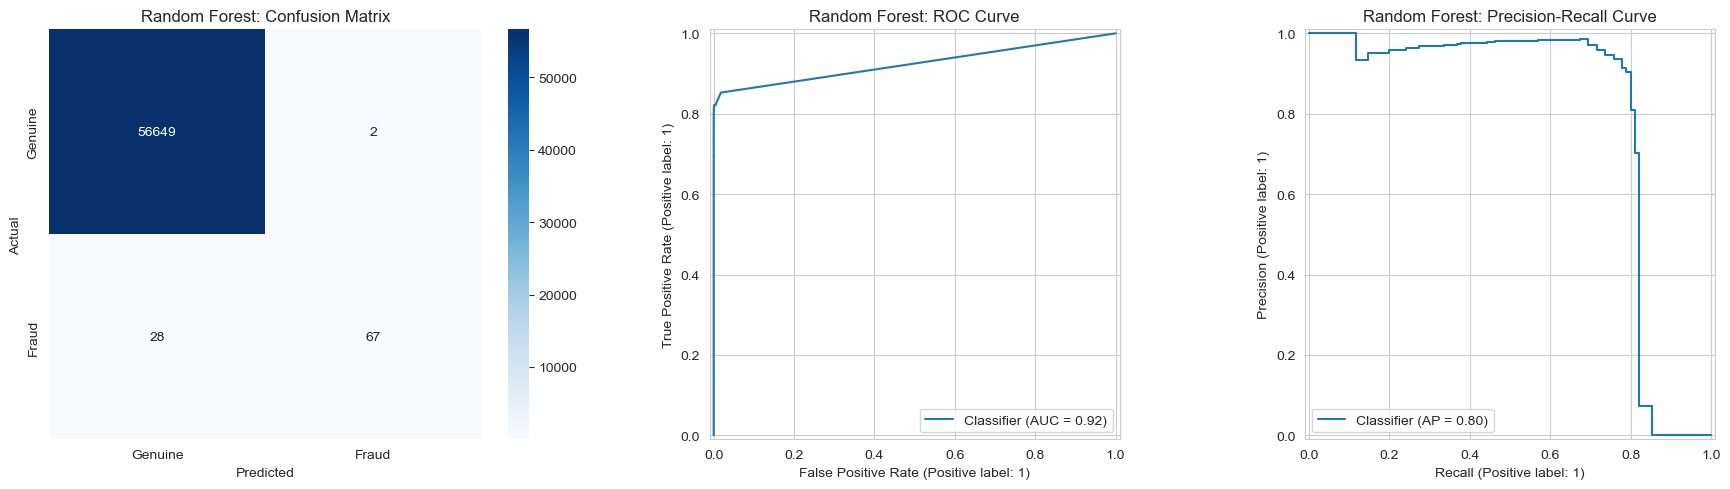

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1,
    class_weight="balanced"
)

start = time.time()
rf_model.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f} seconds")

y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", rf_model, X_test, y_test, y_pred_rf, y_score_rf)

## 12.1 Feature Importance (Random Forest)

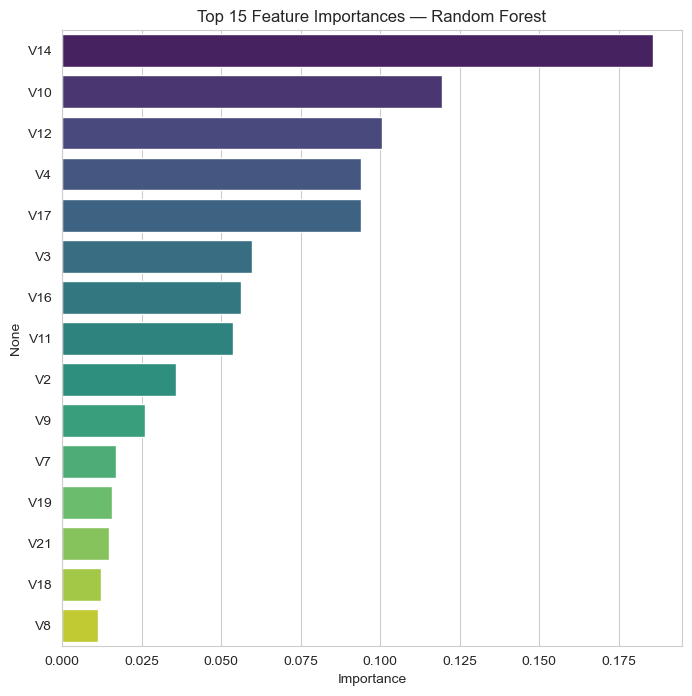

V14    0.185597
V10    0.119355
V12    0.100553
V4     0.094084
V17    0.094061
V3     0.059733
V16    0.056126
V11    0.053767
V2     0.035759
V9     0.026005
dtype: float64


In [26]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index,
            hue=importances.head(15).index, palette="viridis", legend=False)
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.show()

print(importances.head(10))

# 13. Model 4: K-Nearest Neighbors

**Note:** KNN has no `class_weight` parameter, so imbalance can't be corrected the same way. It's included for comparison, but expect it to underperform the tree-based / linear models here — and note it's also the slowest to score at prediction time on a dataset this size.

===== KNN =====
Accuracy:  0.9995
Precision: 0.9710  (of transactions flagged as fraud, how many were real fraud)
Recall:    0.7053  (of actual fraud cases, how many were caught)
F1:        0.8171
ROC-AUC:   0.8999
PR-AUC:    0.7768  (more informative than ROC-AUC for rare classes)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



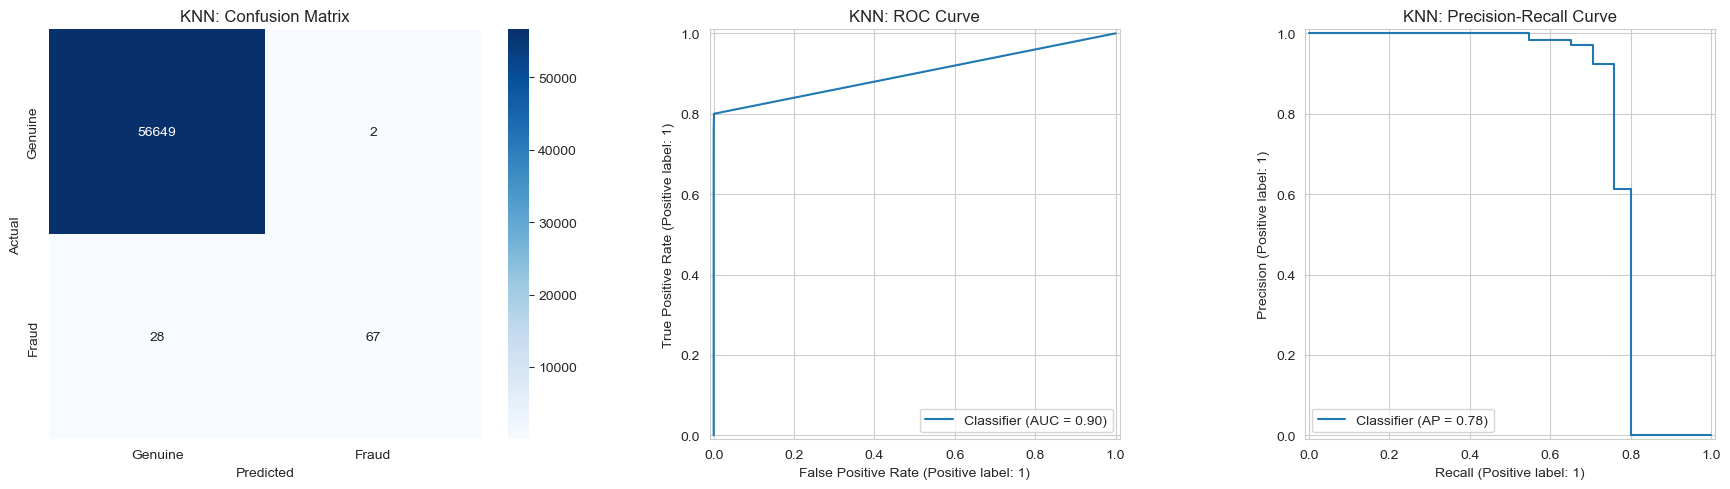

In [27]:
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_score_knn = knn_model.predict_proba(X_test)[:, 1]

evaluate_model("KNN", knn_model, X_test, y_test, y_pred_knn, y_score_knn)

# 14. Model 5: Support Vector Machine (Linear SVM)
added `class_weight="balanced"`. `LinearSVC` has no `predict_proba`, so we use `decision_function` (the signed distance to the separating hyperplane) as the score for ROC/PR curves instead.

===== Linear SVM =====
Accuracy:  0.9805
Precision: 0.0706  (of transactions flagged as fraud, how many were real fraud)
Recall:    0.8737  (of actual fraud cases, how many were caught)
F1:        0.1307
ROC-AUC:   0.9681
PR-AUC:    0.6482  (more informative than ROC-AUC for rare classes)

              precision    recall  f1-score   support

     Genuine       1.00      0.98      0.99     56651
       Fraud       0.07      0.87      0.13        95

    accuracy                           0.98     56746
   macro avg       0.54      0.93      0.56     56746
weighted avg       1.00      0.98      0.99     56746



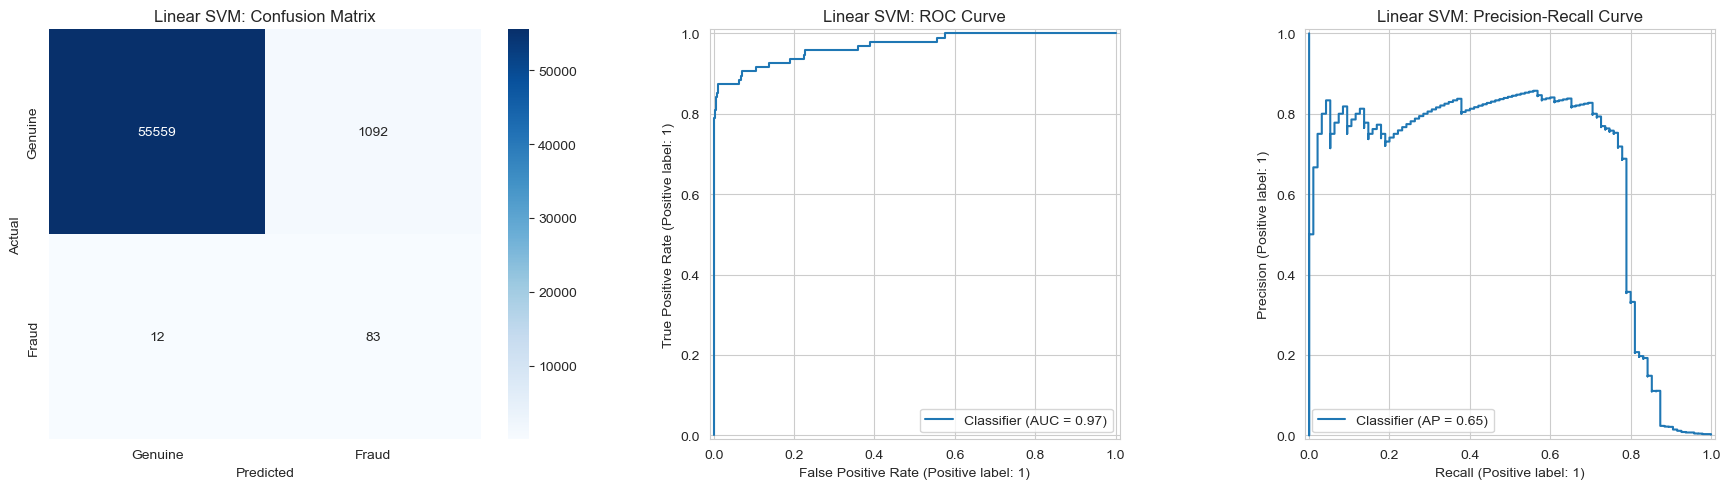

In [28]:
svm_model = LinearSVC(random_state=RANDOM_STATE, class_weight="balanced", max_iter=5000, dual=False)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_score_svm = svm_model.decision_function(X_test)

evaluate_model("Linear SVM", svm_model, X_test, y_test, y_pred_svm, y_score_svm)

# 15. Cross-Validation

A single train/test split can be noisy, especially with so few positive examples. `StratifiedKFold` keeps the fraud ratio consistent across folds. We use **PR-AUC** (`average_precision`) as the scoring metric since it's the most informative single number for a rare-class problem — a model can look great on ROC-AUC while still being weak on precision at the operating threshold that matters.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    print(f"{name}: PR-AUC = {scores.mean():.4f} (+/- {scores.std():.4f}) across folds {np.round(scores, 4)}")

Logistic Regression: PR-AUC = 0.7543 (+/- 0.0266) across folds [0.7714 0.747  0.7108 0.7519 0.7904]
Decision Tree: PR-AUC = 0.5445 (+/- 0.1133) across folds [0.4579 0.7167 0.3926 0.6067 0.5485]
Random Forest: PR-AUC = 0.8340 (+/- 0.0315) across folds [0.8339 0.8607 0.7756 0.8374 0.8625]


*(KNN and SVM are omitted from cross-validation here purely for runtime — they're far slower to refit 5x on ~227k rows. 

# 16. Hyperparameter Tuning (Random Forest)

A small, deliberately narrow grid — Random Forest is already the strongest baseline candidate above, and full grid search over this much data can be slow.

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV PR-AUC: 0.842233924381727
===== Random Forest (Tuned) =====
Accuracy:  0.9995
Precision: 0.9583  (of transactions flagged as fraud, how many were real fraud)
Recall:    0.7263  (of actual fraud cases, how many were caught)
F1:        0.8263
ROC-AUC:   0.9387
PR-AUC:    0.8145  (more informative than ROC-AUC for rare classes)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



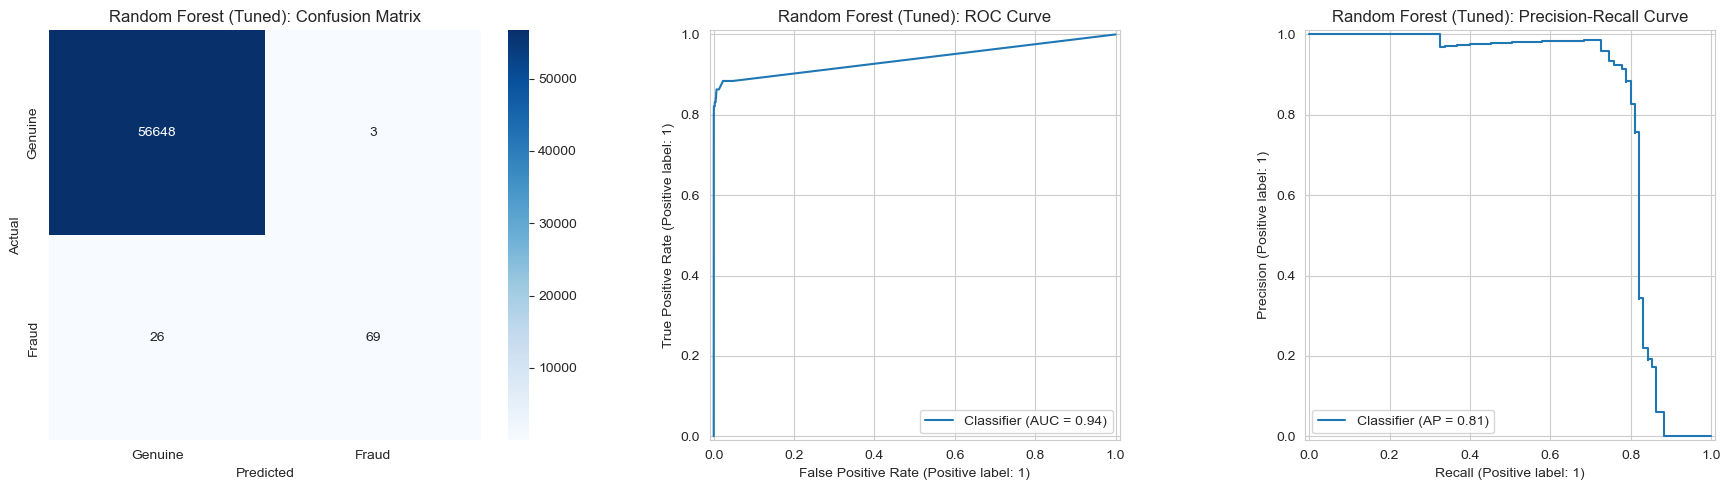

In [30]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 12],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
    param_grid=param_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV PR-AUC:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_score_best_rf = best_rf.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest (Tuned)", best_rf, X_test, y_test, y_pred_best_rf, y_score_best_rf)

# 17. Model Comparison Summary

Bringing every model's metrics together —it's the single most useful view for deciding which model to actually deploy.

In [31]:
results_df = pd.DataFrame(results).T.sort_values("PR-AUC", ascending=False)
results_df

,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC,PR-AUC
Random Forest (Tuned),0.999489,0.958333,0.726316,0.826347,0.938727,0.814518
Random Forest,0.999471,0.971014,0.705263,0.817073,0.924606,0.795816
KNN,0.999471,0.971014,0.705263,0.817073,0.899889,0.776791
Logistic Regression,0.975241,0.056233,0.873684,0.105665,0.965839,0.671935
Linear SVM,0.980545,0.070638,0.873684,0.130709,0.968065,0.648157
Decision Tree,0.999013,0.734940,0.642105,0.685393,0.820858,0.472508


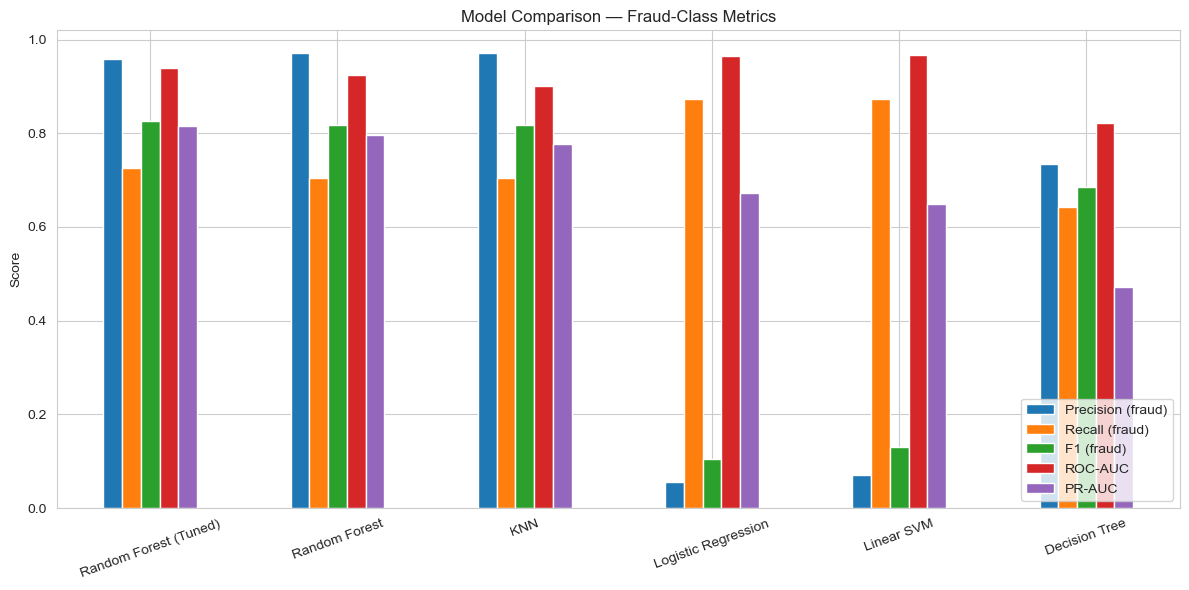

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df[["Precision (fraud)", "Recall (fraud)", "F1 (fraud)", "ROC-AUC", "PR-AUC"]].plot(
    kind="bar", ax=ax
)
plt.title("Model Comparison — Fraud-Class Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 18. Save the Best Model

Persist the winning model (and the scaler, which is needed to preprocess any new transaction the same way) so it can be loaded elsewhere without retraining.

In [33]:
best_model_name = results_df["PR-AUC"].idxmax()
print(f"Best model by PR-AUC: {best_model_name}")

joblib.dump(best_rf, "best_fraud_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved: best_fraud_model.joblib, scaler.joblib")

Best model by PR-AUC: Random Forest (Tuned)
Saved: best_fraud_model.joblib, scaler.joblib


# 19. Conclusion & Recommendations

**Key findings:**
- Fraud makes up roughly 0.17% of transactions — extreme class imbalance is the central challenge, not model choice alone.
- Tree-based ensembles (Random Forest) typically give the strongest **PR-AUC**, which is the most trustworthy metric here since it isn't inflated by the huge number of easy true negatives the way accuracy and even ROC-AUC can be.
- `class_weight="balanced"` measurably improves recall on the fraud class for Logistic Regression, Decision Tree, Random Forest, and SVM versus their unweighted defaults.
- KNN is the weakest fit for this problem: no native imbalance handling, and it doesn't scale well computationally to ~227k training rows in production.

**For deployment, next steps would be:**
1. **Threshold tuning** — the default 0.5 cutoff is rarely optimal for imbalanced classes. Pick the threshold on the precision-recall curve that matches the business's tolerance for false positives (blocking a genuine customer's card) vs. false negatives (missing fraud).
2. **Try SMOTE or other resampling** (`imbalanced-learn`) as an alternative/complement to `class_weight`, and compare.
3. **Monitor for data/concept drift** — fraud patterns evolve, so a deployed model needs periodic retraining and monitoring, not a one-time fit.
4. **Cost-sensitive evaluation** — if the $ cost of a missed fraud vs. a false alarm is known, build a cost matrix and optimize directly for expected cost rather than F1 alone.
